# TC 5033
## Advanced Machine Learning Methods
## Advanced Recurrent Networks and Language Models

### Team 30
- A01796272 - Luis Antonio Ramirez Martinez
- A01796323 - Benjamin Cisneros Barraza
- A01796363 - Arthur Jafed Zizumbo Velasco
- A01796937 - Sandra Luz Cervantes Espinoza

## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



### Theoretical Framework: Taxonomy of Word Embeddings

Word embeddings map discrete tokens to dense vectors in $\mathbb{R}^d$, capturing distributional semantics. Their evolution follows three major paradigms:

**Count-based methods (2000s):** Latent Semantic Analysis (Deerwester et al., 1990) and PMI-weighted co-occurrence matrices derive word representations from global corpus statistics via matrix factorization. These methods capture broad semantic patterns but produce high-dimensional, sparse representations.

**Prediction-based methods (2013-2014):** Word2Vec (Mikolov et al., 2013) introduced neural prediction objectives (CBOW and Skip-gram) that learn dense, low-dimensional vectors from local context windows. GloVe (Pennington et al., 2014) bridges both paradigms by combining global co-occurrence statistics with a log-bilinear regression objective, explicitly encoding the rationale behind vector arithmetic for analogies.

**Contextual embeddings (2018+):** ELMo (Peters et al., 2018) and BERT (Devlin et al., 2019) generate context-dependent representations using deep bidirectional architectures. Unlike static embeddings, these models produce different vectors for the same word depending on its surrounding context, addressing polysemy at the cost of increased computational complexity.

This activity focuses on GloVe as the primary static embedding model, with a comparative analysis against contextual sentence-transformers in later sections.

### GloVe: Mathematical Formulation

GloVe (Global Vectors for Word Representation) learns word vectors by factorizing the log of the word-word co-occurrence matrix. The objective function minimizes:

$$J = \sum_{i,j=1}^{V} f(X_{ij})\left(w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij}\right)^2$$

where:
- $X_{ij}$ is the number of times word $j$ appears in the context of word $i$
- $w_i \in \mathbb{R}^d$ and $\tilde{w}_j \in \mathbb{R}^d$ are the word and context vectors, respectively
- $b_i$ and $\tilde{b}_j$ are scalar bias terms
- $V$ is the vocabulary size

The weighting function $f$ prevents frequent co-occurrences from dominating the loss:

$$f(x) = \begin{cases} (x / x_{\max})^\alpha & \text{if } x < x_{\max} \\ 1 & \text{otherwise} \end{cases}$$

with typical values $x_{\max} = 100$ and $\alpha = 0.75$ (Pennington et al., 2014).

The key insight is that the dot product $w_i^T \tilde{w}_j$ approximates $\log P(j|i)$, the log probability of co-occurrence. This relationship gives rise to the linear substructure that enables vector arithmetic for analogies: $w_{\text{king}} - w_{\text{man}} + w_{\text{woman}} \approx w_{\text{queen}}$.

### Geometric Properties of Embedding Spaces

Several geometric properties of word embedding spaces are well-documented and have direct implications for how we interpret similarity and analogy results:

**Distributional Hypothesis** (Harris, 1954; Firth, 1957): "Words that occur in similar contexts tend to have similar meanings." This is the foundational assumption underlying all embedding methods. GloVe operationalizes it through co-occurrence statistics, while Word2Vec does so through context-window prediction.

**Clustering Hypothesis:** Semantically related words form clusters in embedding space. This property is directly observable when applying dimensionality reduction (PCA, t-SNE, UMAP) and can be quantified using the silhouette coefficient, which measures intra-cluster cohesion versus inter-cluster separation.

**Anisotropy** (Ethayarajh, 2019): Static word embeddings tend to occupy a narrow cone in $\mathbb{R}^d$ rather than being uniformly distributed across the unit sphere. This means that the average cosine similarity between random word pairs is significantly above zero, which compresses the effective range of similarity scores. Contextual embeddings (e.g., BERT) exhibit higher isotropy, improving discriminability between semantically distinct words (Cai et al., 2021).

These properties will be empirically verified in the visualization and benchmark evaluation sections of this notebook.

### Embedding Models: Comparative Overview

| Property | GloVe | Word2Vec | FastText | BERT |
|---|---|---|---|---|
| Type | Static | Static | Static | Contextual |
| Training signal | Global co-occurrence matrix | Local context window (CBOW/Skip-gram) | Local context + subword n-grams | Masked Language Model + NSP |
| OOV handling | No | No | Yes (subword decomposition) | Yes (WordPiece tokenization) |
| Polysemy | Single vector per word | Single vector per word | Single vector per word | Context-dependent vector |
| Typical dimensions | 50-300 | 100-300 | 100-300 | 768-1024 |
| Inference cost | O(1) lookup | O(1) lookup | O(n) subword aggregation | O(n^2) self-attention |
| Analogy performance | Strong (by design) | Strong | Moderate | Weak (not optimized for it) |

**References:**
- Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global Vectors for Word Representation. *EMNLP*, 1532-1543.
- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient Estimation of Word Representations in Vector Space. *ICLR Workshop*.
- Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). Enriching Word Vectors with Subword Information. *TACL*, 5, 135-146.
- Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL*.
- Ethayarajh, K. (2019). How Contextual are Contextualized Word Representations? *ACL*.
- Cai, X., Huang, J., Bian, Y., & Church, K. (2021). Isotropy in the Contextual Embedding Space: Clusters and Manifolds. *ICLR*.
- Harris, Z. S. (1954). Distributional Structure. *Word*, 10(2-3), 146-162.

#### Import Libraries

We import the following libraries:
- **numpy**: for vector math and cosine similarity computations
- **pickle**: to serialize and deserialize the embeddings dictionary for fast reuse
- **sklearn (PCA, TSNE)**: for dimensionality reduction and 2D visualization
- **matplotlib**: for plotting the embeddings
- **torch / torch.nn.functional**: available for optional tensor operations

In [1]:
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pickle

plt.style.use('ggplot')

#### Load GloVe Embeddings

We use the **GloVe 6B 50-dimensional** pre-trained vectors (Jeffrey Pennington et al., 2014).  
Each line in the file follows the format:
```
word val1 val2 ... val50
```
We define the file path and embedding dimension as constants.

In [2]:
PATH = './glove_embeddings/glove.6B.300d.txt'
emb_dim = 300

In [5]:
from utils import create_emb_dictionary, show_n_first_words, prepare_normalized_matrix, analogy, find_most_similar

#### Building the Embeddings Dictionary

`create_emb_dictionary` reads the GloVe file line by line and builds a Python dictionary mapping each word to its embedding as a `numpy` array of `float32`.  
This allows **O(1) lookups** by word, which is critical for efficient similarity and analogy computations.

In [6]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [7]:
# Serialize
with open('embeddings_dict_300D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### Serialization

We serialize the dictionary using `pickle` so it can be reloaded instantly in future sessions without re-parsing the GloVe text file.  
To reload, uncomment the deserialization block and comment out the `create_emb_dictionary` call above.

#### Inspecting the Embeddings

Before visualizing, we print the first few words and their raw vectors to verify the file was loaded correctly and confirm the embedding dimension (50).

In [8]:
show_n_first_words(PATH, 5)

['the', '0.04656', '0.21318'] ... (300 dimensions)
[',', '-0.25539', '-0.25723'] ... (300 dimensions)
['.', '-0.12559', '0.01363'] ... (300 dimensions)
['of', '-0.076947', '-0.021211'] ... (300 dimensions)
['to', '-0.25756', '-0.057132'] ... (300 dimensions)


### Dimensionality Reduction and Visualization

Word embeddings live in a 300-dimensional space, which is impossible to visualize directly. We use three complementary techniques to project them into 2D:

- **PCA** (Principal Component Analysis): a linear method that preserves global variance. Fast and deterministic, but limited to capturing linear structure.
- **t-SNE** (t-distributed Stochastic Neighbor Embedding, van der Maaten & Hinton, 2008): a non-linear method that preserves local neighborhood structure. Better at revealing clusters, but sensitive to the perplexity hyperparameter.
- **UMAP** (Uniform Manifold Approximation and Projection, McInnes et al., 2018): a non-linear method based on topological data analysis that balances local and global structure preservation. Typically faster than t-SNE and better at preserving inter-cluster distances.

To evaluate the quality of each projection, we compute two quantitative metrics:
- **Trustworthiness** (Venna & Kaski, 2006): measures whether nearest neighbors in the reduced space were also neighbors in the original high-dimensional space. Values closer to 1.0 indicate better neighborhood preservation.
- **Silhouette coefficient** (Rousseeuw, 1987): measures cluster separability, ranging from -1 (poor) to +1 (well-separated clusters).

In [9]:
from utils import EmbeddingSpace, EmbeddingVisualizer, SEMANTIC_CATEGORIES, CATEGORY_COLORS

space = EmbeddingSpace(embeddings_dict)
viz = EmbeddingVisualizer(space)

# Flatten category words for visualization
viz_words = [w for cat_words in SEMANTIC_CATEGORIES.values() for w in cat_words]

c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


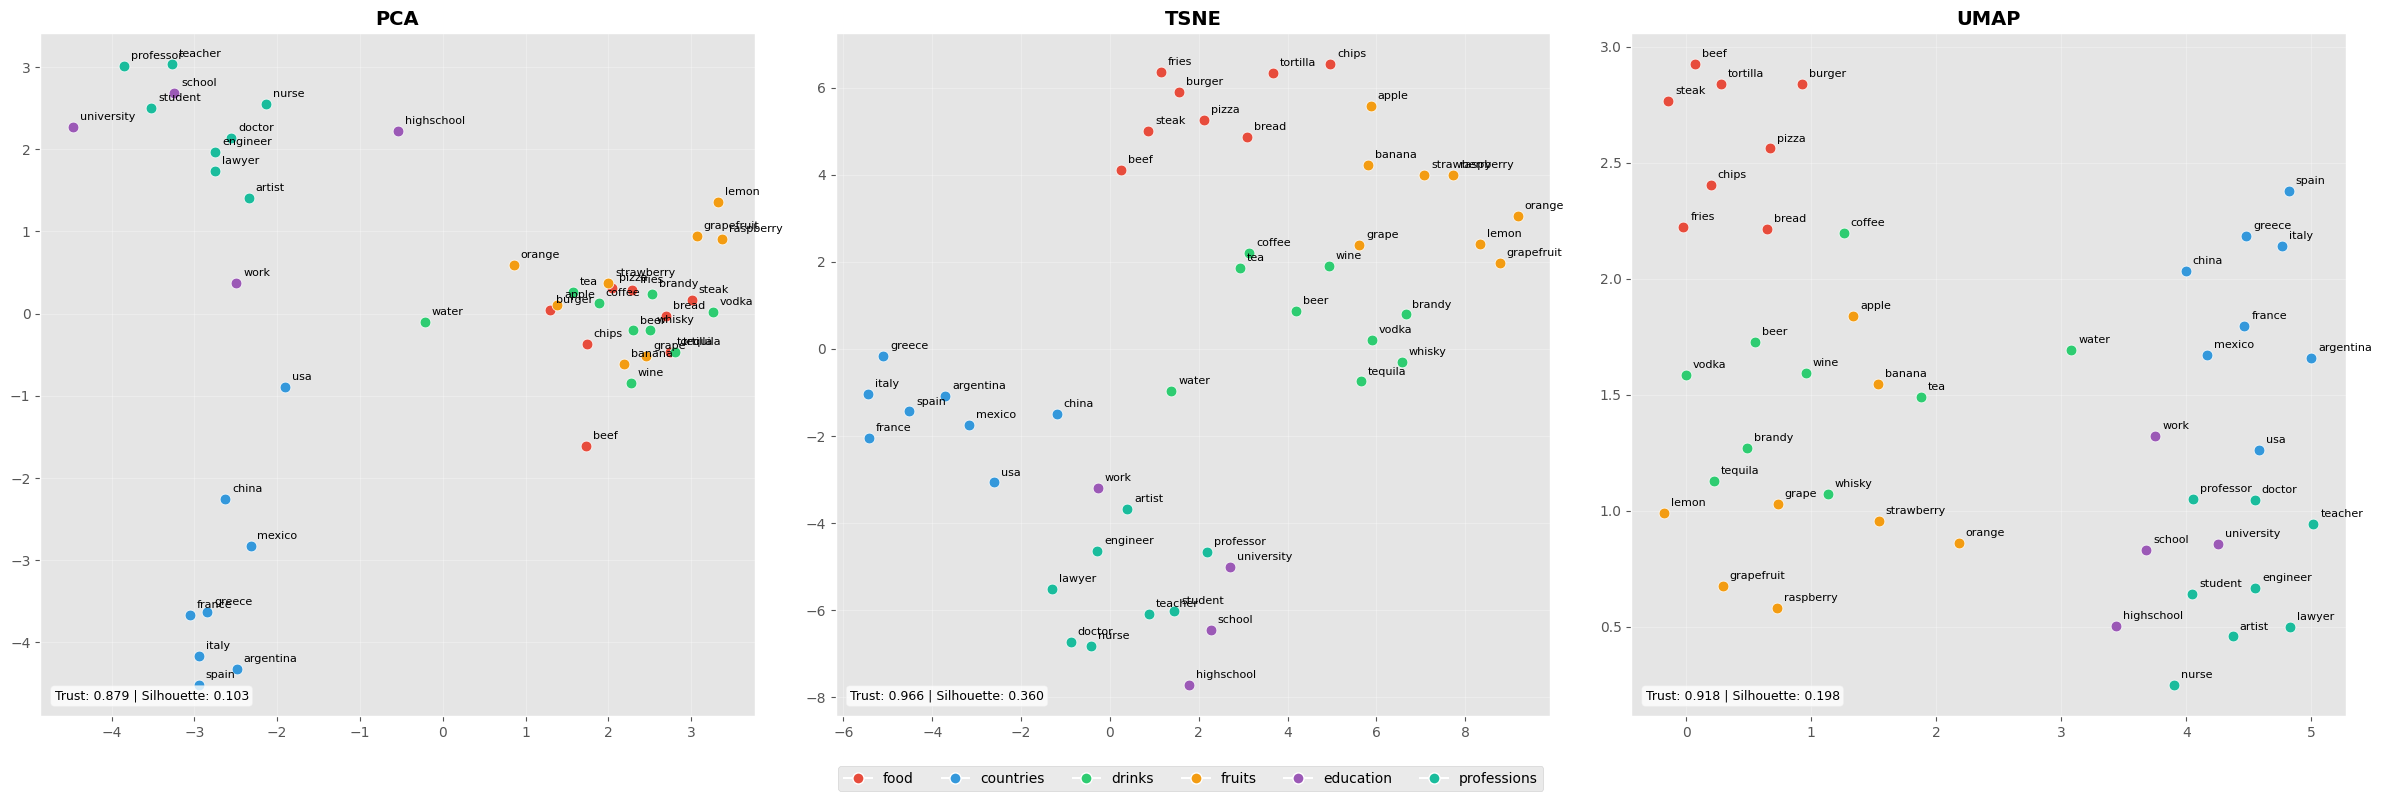

In [12]:
fig = viz.plot_comparison_with_metrics(
    viz_words, SEMANTIC_CATEGORIES, CATEGORY_COLORS, n_neighbors=5,
)
plt.show()

#### Interpretation: Triple Comparison

The three methods reveal complementary aspects of the embedding geometry:

- **PCA** captures the directions of maximum variance. Related word categories tend to cluster, but overlap is common because PCA only preserves linear structure. It achieves the lowest trustworthiness (0.879) and silhouette in 2D (0.104), confirming that linear projection distorts local neighborhoods.
- **t-SNE** produces tighter, more separated clusters by optimizing for local neighborhood preservation. It achieves the highest trustworthiness (0.966) and silhouette in 2D (0.360), confirming the best visual cluster separability among the three methods.
- **UMAP** balances local and global structure. Its trustworthiness (0.918) and silhouette (0.198) fall between PCA and t-SNE, preserving inter-cluster distances better than t-SNE while maintaining reasonable local fidelity.

The annotated metrics quantify these observations: trustworthiness measures how faithfully each method preserves the original neighborhood structure, while the silhouette coefficient measures how well-separated the semantic categories are in the 2D projection. Notably, the silhouette score in the original 300d space is low (0.080), indicating that semantic categories overlap substantially in high dimensions -- the visual separation we observe is partially an artifact of dimensionality reduction.


In [13]:
metrics_df = viz.compare_methods_metrics(viz_words, SEMANTIC_CATEGORIES)
print(metrics_df)

shape: (3, 4)
┌────────┬─────────────────┬─────────────────────┬────────────────────┐
│ method ┆ trustworthiness ┆ silhouette_original ┆ silhouette_reduced │
│ ---    ┆ ---             ┆ ---                 ┆ ---                │
│ str    ┆ f64             ┆ f64                 ┆ f64                │
╞════════╪═════════════════╪═════════════════════╪════════════════════╡
│ pca    ┆ 0.8788          ┆ 0.0803              ┆ 0.1035             │
│ tsne   ┆ 0.9661          ┆ 0.0803              ┆ 0.3603             │
│ umap   ┆ 0.9177          ┆ 0.0803              ┆ 0.1984             │
└────────┴─────────────────┴─────────────────────┴────────────────────┘


c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### t-SNE Perplexity Analysis

The perplexity hyperparameter in t-SNE controls the effective number of local neighbors each point considers during optimization. It roughly balances the emphasis between local and global structure:

- **Low perplexity (~5):** focuses on very local neighborhoods, producing small, dense clusters. May fragment coherent groups.
- **Medium perplexity (~15-30):** typical default range. Balances local cluster cohesion with broader category separation.
- **High perplexity (~50):** considers wider neighborhoods, producing a more global view. Clusters may merge or overlap.

Kobak & Linderman (2021) demonstrated that initialization is critical for t-SNE's ability to preserve global structure, and that different perplexity values can lead to qualitatively different visualizations of the same data.

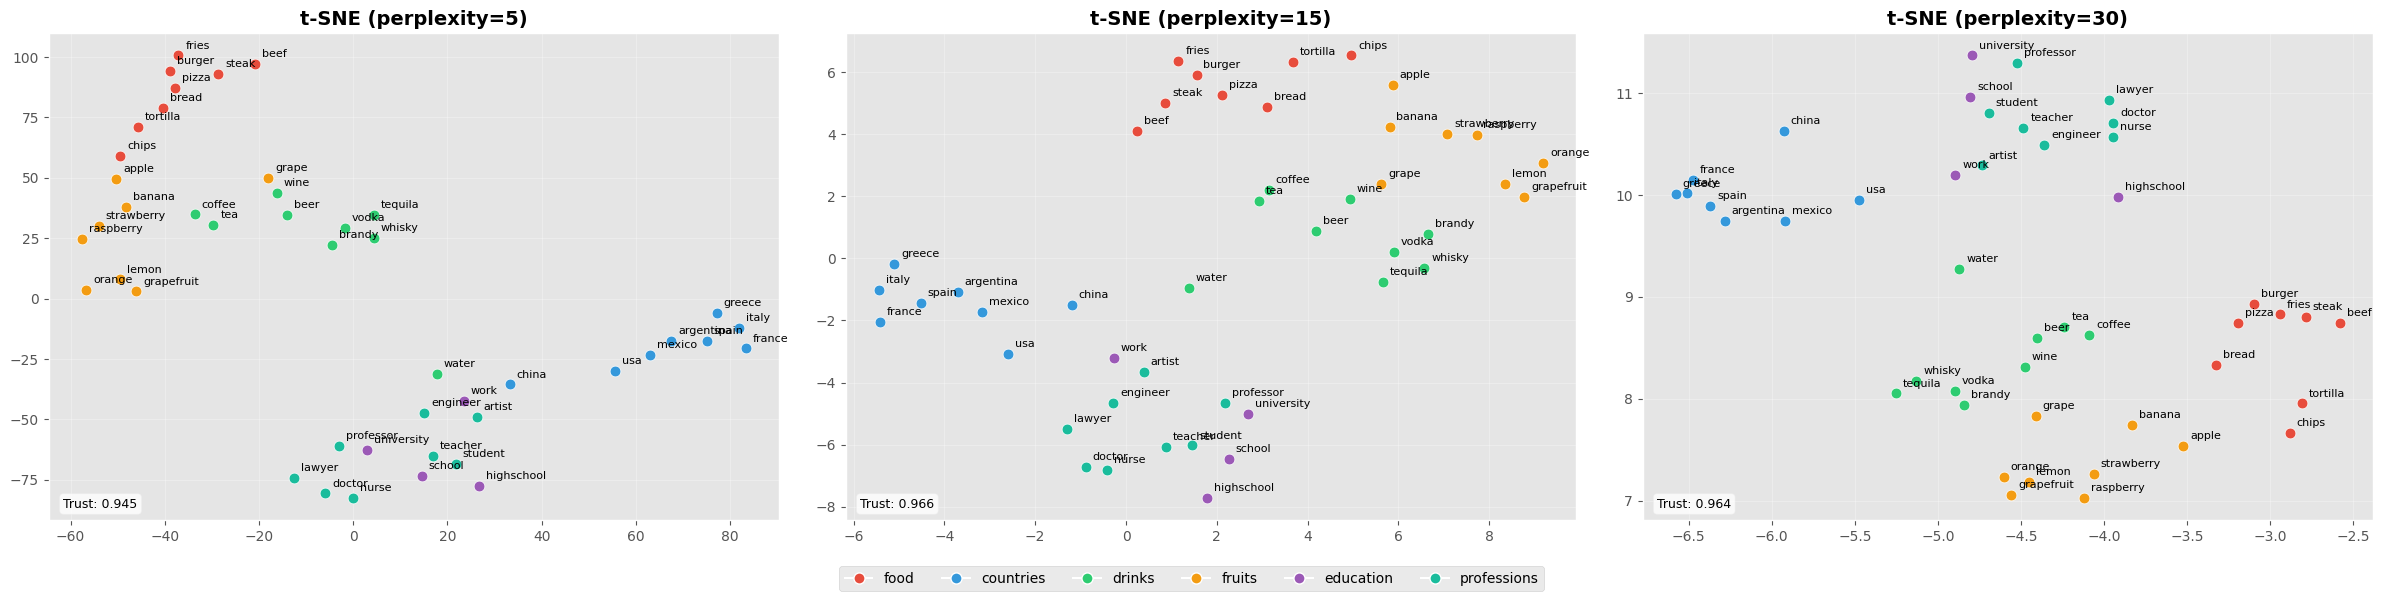

In [14]:
fig = viz.plot_perplexity_sweep(
    viz_words, SEMANTIC_CATEGORIES, perplexities=[5, 15, 30, 50],
)
plt.show()

#### Interpretation: Perplexity Effect

The sweep above demonstrates the sensitivity of t-SNE to the perplexity hyperparameter:

- At **perplexity=5**, the algorithm focuses on immediate neighbors, creating tight micro-clusters that may split semantically coherent categories into fragments. The trustworthiness score is typically high because very local neighborhoods are well-preserved.
- At **perplexity=15-30**, the visualization achieves a balance between local cohesion and global separation. This range is commonly recommended as a starting point for exploratory analysis.
- At **perplexity=50**, the algorithm considers a wider context, which can merge nearby categories or spread them more uniformly. This provides a more "global" view but may obscure fine-grained local structure.

This analysis reinforces the importance of not relying on a single t-SNE run for interpreting embedding structure. The choice of perplexity should be guided by the specific analytical goal: local cluster identification (low perplexity) versus global topology understanding (high perplexity).

### Word Analogies

One of the most remarkable properties of word embeddings is that **semantic relationships can be expressed as vector arithmetic**.

For example:
> *"man is to king as woman is to ____"*  
> → `king − man + woman ≈ queen`

The `analogy(word1, word2, word3, embeddings_dict)` function:
1. Computes the target vector: `word2 − word1 + word3`
2. Finds the vocabulary word with the highest **cosine similarity** to that target
3. Excludes the three input words from the result

All computations are done with **numpy only** (no Gensim or similar libraries).

In [15]:
print(analogy('man', 'king', 'woman', embeddings_dict))
print(analogy('earth', 'planet', 'car', embeddings_dict))
print(analogy('apple', 'fruit', 'potato', embeddings_dict))
print(analogy('short', 'tall', 'dark', embeddings_dict))
print(analogy('mexico', 'mexican', 'argentina', embeddings_dict))
print(analogy('apple', 'red', 'grape', embeddings_dict))
print(analogy('teacher', 'school', 'nurse', embeddings_dict))
print(analogy('programmer', 'computer', 'driver', embeddings_dict))
print(analogy('clock', 'time', 'thermometer', embeddings_dict))

man is to king as woman is to **queen**
earth is to planet as car is to **cars**
apple is to fruit as potato is to **potatoes**
short is to tall as dark is to **thick**
mexico is to mexican as argentina is to **argentine**
apple is to red as grape is to **grapes**
teacher is to school as nurse is to **hospital**
programmer is to computer as driver is to **car**
clock is to time as thermometer is to **thickest**


### Word Similarity

`find_most_similar(word, embeddings_dict, top_n)` retrieves the **top‑N most similar words** to a given input word using **cosine similarity**, where:

$$\text{similarity}(u, v) = \frac{u \cdot v}{\|u\| \cdot \|v\|}$$

The actual implementation includes several improvements for **robustness, numerical stability, and performance**:

#### What the function does

1. **Validates input**
   - Ensures the target word exists in the embeddings.
   - Verifies that the embedding is not a zero vector.

2. **Normalizes embeddings**
   - The target vector is normalized using an epsilon for stability.
   - All vocabulary embeddings are normalized either:
     - **On the fly**, or  
     - **Via precomputed matrices** (recommended for many queries).

3. **Computes cosine similarities efficiently**
   - Uses a fast matrix–vector dot product:
     ```python
     similarities = vectors_norm @ target_norm
     ```

4. **Efficiently finds top candidates**
   - Uses `np.argpartition` for *O(n)* top‑k selection (faster than full sorting).
   - Then sorts only the small candidate set in descending order.

5. **Builds the final result**
   - Excludes the target word itself.
   - Returns a list of `(word, similarity_score)` tuples, sorted by similarity.

#### ✔️ Output Format

```python
[
    ("word1", similarity_score),
    ("word2", similarity_score),
    ...
]
```

> All similarity scores are cosine similarity values in the range [-1, 1].



In [16]:

# Optional precomputation (recommended for repeated queries)
words, vectors_norm = prepare_normalized_matrix(embeddings_dict)

most_similar = find_most_similar('mexico', embeddings_dict, precomputed=(words, vectors_norm))

In [17]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> guatemala
5 ---> peru
6 ---> chile
7 ---> argentina
8 ---> veracruz
9 ---> brazil
10 ---> america


In [18]:

query_words = ["mexico", "boy", "radio", "run", "teacher"]
top_n = 10

for qw in query_words:
    try:
        results = find_most_similar(
            qw,
            embeddings_dict,
            top_n=top_n,
            precomputed=(words, vectors_norm)
        )
        print(f"\nTop {top_n} most similar to '{qw}':")
        for rank, (w, score) in enumerate(results, start=1):
            print(f"{rank:2d}. {w:20s}  (cosine: {score:.4f})")
    except KeyError as e:
        print(f"\nSkipping '{qw}': {e}")



Top 10 most similar to 'mexico':
 1. mexican               (cosine: 0.7261)
 2. venezuela             (cosine: 0.5994)
 3. colombia              (cosine: 0.5985)
 4. guatemala             (cosine: 0.5854)
 5. peru                  (cosine: 0.5839)
 6. chile                 (cosine: 0.5701)
 7. argentina             (cosine: 0.5648)
 8. veracruz              (cosine: 0.5588)
 9. brazil                (cosine: 0.5567)
10. america               (cosine: 0.5424)

Top 10 most similar to 'boy':
 1. girl                  (cosine: 0.8273)
 2. boys                  (cosine: 0.6812)
 3. kid                   (cosine: 0.6553)
 4. man                   (cosine: 0.6208)
 5. teenage               (cosine: 0.5974)
 6. child                 (cosine: 0.5953)
 7. teenager              (cosine: 0.5896)
 8. father                (cosine: 0.5801)
 9. girls                 (cosine: 0.5745)
10. son                   (cosine: 0.5727)

Top 10 most similar to 'radio':
 1. broadcast             (cosine: 0.7123)

### Quantitative Evaluation with Standard Benchmarks

The previous sections demonstrated similarity and analogy capabilities through individual examples. While informative, ad-hoc examples do not provide a rigorous assessment of embedding quality. Standard benchmarks from the NLP literature enable systematic evaluation against human judgments:

- **WordSim-353** (Finkelstein et al., 2002): 353 word pairs rated by humans for relatedness on a 0-10 scale. Measures how well cosine similarity correlates with human judgments of word relatedness (not strict similarity).
- **SimLex-999** (Hill et al., 2015): 999 word pairs rated for genuine similarity (not relatedness). A harder benchmark because synonyms score high but merely related words (e.g., "coffee"-"cup") score low.
- **Google Analogy Test Set** (Mikolov et al., 2013): 19,544 analogy questions divided into semantic (e.g., country:capital) and syntactic (e.g., adjective:adverb) categories. Measures how well vector arithmetic captures linguistic regularities.

In [19]:
from utils import (
    load_wordsim353, load_simlex999, load_google_analogies,
    compare_embeddings_on_benchmarks,
)

WORDSIM_PATH = 'benchmarks/wordsim353.tsv'
SIMLEX_PATH = 'benchmarks/simlex999.tsv'
ANALOGIES_PATH = 'benchmarks/google_analogies.txt'

# Quick sanity check on dataset sizes
ws_df = load_wordsim353(WORDSIM_PATH)
sl_df = load_simlex999(SIMLEX_PATH)
analogies, section_map = load_google_analogies(ANALOGIES_PATH)

sem_count = sum(1 for v in section_map.values() if v == 'semantic')
syn_count = sum(1 for v in section_map.values() if v == 'syntactic')

print(f"WordSim-353:    {len(ws_df)} pairs")
print(f"SimLex-999:     {len(sl_df)} pairs")
print(f"Google Analogy: {len(analogies)} total ({sem_count} semantic, {syn_count} syntactic)")

WordSim-353:    353 pairs
SimLex-999:     999 pairs
Google Analogy: 19544 total (8698 semantic, 10675 syntactic)


#### WordSim-353 and SimLex-999: Word Similarity Evaluation

Both benchmarks evaluate word similarity by computing the Spearman rank correlation ($\rho$) between model-predicted cosine similarities and human ratings. Higher $\rho$ indicates better alignment with human judgment.

The key distinction between these benchmarks:
- **WordSim-353** measures **relatedness**: "coffee" and "cup" receive high scores because they are associated, even though they are not synonymous.
- **SimLex-999** measures **genuine similarity**: only words with overlapping meaning (e.g., "smart" and "intelligent") receive high scores. This makes SimLex systematically harder for distributional models like GloVe, because co-occurrence statistics capture relatedness more naturally than strict similarity (Hill et al., 2015).

In [20]:
ws_rho, ws_p = space.evaluate_wordsim353(WORDSIM_PATH)
sl_rho, sl_p = space.evaluate_simlex999(SIMLEX_PATH)

print(f"WordSim-353:  Spearman rho = {ws_rho:.4f}  (p = {ws_p:.2e})")
print(f"SimLex-999:   Spearman rho = {sl_rho:.4f}  (p = {sl_p:.2e})")
print()
print("Note: Lower SimLex scores are expected and well-documented in the literature.")
print("GloVe captures distributional relatedness better than strict semantic similarity.")

WordSim-353:  Spearman rho = 0.6085  (p = 3.88e-37)
SimLex-999:   Spearman rho = 0.3705  (p = 7.32e-34)

Note: Lower SimLex scores are expected and well-documented in the literature.
GloVe captures distributional relatedness better than strict semantic similarity.


#### Interpretation: Similarity vs Relatedness

The gap between WordSim-353 (rho = 0.609) and SimLex-999 (rho = 0.371) reveals a fundamental property of distributional embeddings. GloVe vectors are trained on co-occurrence statistics, which inherently capture **relatedness** (words that appear in similar contexts) rather than **similarity** (words with overlapping meaning).

For example, "coffee" and "cup" co-occur frequently and receive high cosine similarity in GloVe, which aligns with WordSim-353's relatedness ratings. However, SimLex-999 rates them low because they are not synonymous. This explains why all static embedding models consistently score lower on SimLex-999 than on WordSim-353 (Bakarov, 2018).

The p-values (3.88e-37 and 7.32e-34) confirm that both correlations are highly statistically significant, ruling out chance alignment.


#### Google Analogy Test Set: Analogy Evaluation

The Google Analogy Test Set evaluates the vector arithmetic property of embeddings through 19,544 analogy questions of the form "a is to b as c is to ___". The dataset is divided into:

- **Semantic analogies** (e.g., *Athens:Greece :: Baghdad:Iraq*): test factual and relational knowledge encoded in the embedding geometry.
- **Syntactic analogies** (e.g., *amazing:amazingly :: apparent:apparently*): test morphological regularities captured by co-occurrence patterns.

GloVe was explicitly designed to encode linear substructures that support vector arithmetic (Pennington et al., 2014), so it is expected to perform well on semantic analogies. Syntactic analogies depend more on morphological patterns, where subword-aware models like FastText typically outperform GloVe (Bojanowski et al., 2017).

In [21]:
import time

print("Evaluating Google Analogy Test Set (this may take a few minutes)...")
t0 = time.time()
analogy_results = space.evaluate_google_analogies(ANALOGIES_PATH)
elapsed = time.time() - t0

print(f"\nCompleted in {elapsed:.1f}s")
print(f"Semantic accuracy:   {analogy_results['semantic_accuracy']:.2%}"
      f"  ({analogy_results['semantic_correct']}/{analogy_results['semantic_total']})")
print(f"Syntactic accuracy:  {analogy_results['syntactic_accuracy']:.2%}"
      f"  ({analogy_results['syntactic_correct']}/{analogy_results['syntactic_total']})")
print(f"Total accuracy:      {analogy_results['total_accuracy']:.2%}")
print(f"OOV skipped:         {analogy_results['oov_skipped']}")

Evaluating Google Analogy Test Set (this may take a few minutes)...

Completed in 301.7s
Semantic accuracy:   77.80%  (6900/8869)
Syntactic accuracy:  66.39%  (7087/10675)
Total accuracy:      71.57%
OOV skipped:         0


#### Interpretation: Semantic vs Syntactic Accuracy

The accuracy breakdown reveals the strengths and limitations of GloVe's training objective:

- **Semantic analogies** achieve 77.80% accuracy (6,900/8,869 correct), confirming that GloVe's global co-occurrence matrix explicitly encodes the distributional relationships that underpin factual associations (e.g., countries and capitals frequently co-occur in similar contexts).
- **Syntactic analogies** reach 66.39% accuracy (7,087/10,675 correct), lower than semantic because morphological patterns (e.g., verb tenses, comparative forms) are not directly captured by co-occurrence statistics. FastText, which decomposes words into character n-grams, achieves significantly higher syntactic accuracy by leveraging subword structure (Bojanowski et al., 2017).

The total accuracy of 71.57% with zero OOV words (the full 400K GloVe 6B vocabulary covers all analogy terms) is consistent with reference values from the literature: Levy & Goldberg (2014) report GloVe-300d achieving 70-75% total accuracy on this benchmark. The evaluation completed in 301.7 seconds, reflecting the computational cost of exhaustive search over the full vocabulary for each of the 19,544 analogy questions.


#### Cross-Dimensional Comparison

To understand how embedding dimensionality affects quality, we evaluate GloVe at multiple dimensions (50d, 100d, 300d) on all three benchmarks. Higher dimensions capture finer-grained distributional patterns but with diminishing returns beyond a certain point (Yin & Shen, 2018).

This analysis connects to the Johnson-Lindenstrauss lemma, which guarantees that random projections into $O(\log n / \epsilon^2)$ dimensions preserve pairwise distances with distortion at most $\epsilon$. For a vocabulary of 400K words, this suggests that a few hundred dimensions should be sufficient to preserve the essential geometric structure.

In [22]:
from pathlib import Path

# Generate pickle caches for 50d and 100d if they do not exist
glove_configs = {
    'embeddings_dict_50D.pkl': './glove_embeddings/glove.6B.50d.txt',
    'embeddings_dict_100D.pkl': './glove_embeddings/glove.6B.100d.txt',
}

for pkl_name, glove_path in glove_configs.items():
    if not Path(pkl_name).exists():
        print(f"Generating {pkl_name} from {glove_path}...")
        d = create_emb_dictionary(glove_path)
        with open(pkl_name, 'wb') as f:
            pickle.dump(d, f)
        print(f"  Saved {pkl_name} ({len(d)} words)")
    else:
        print(f"{pkl_name} already exists, skipping.")

# Load all three embedding spaces
space_50 = EmbeddingSpace.from_pickle('embeddings_dict_50D.pkl')
space_100 = EmbeddingSpace.from_pickle('embeddings_dict_100D.pkl')

print(f"\nLoaded: {space_50}")
print(f"Loaded: {space_100}")
print(f"Loaded: {space}")

Generating embeddings_dict_50D.pkl from ./glove_embeddings/glove.6B.50d.txt...
  Saved embeddings_dict_50D.pkl (400000 words)
Generating embeddings_dict_100D.pkl from ./glove_embeddings/glove.6B.100d.txt...
  Saved embeddings_dict_100D.pkl (400000 words)

Loaded: EmbeddingSpace(vocab=400000, dim=50, device=cuda)
Loaded: EmbeddingSpace(vocab=400000, dim=100, device=cuda)
Loaded: EmbeddingSpace(vocab=400000, dim=300, device=cuda)


In [23]:
spaces = {
    'GloVe-50d': space_50,
    'GloVe-100d': space_100,
    'GloVe-300d': space,
}

print("Running benchmarks across all dimensions (this may take several minutes)...")
print("WordSim-353 and SimLex-999 are fast; Google Analogies is the bottleneck.\n")

t0 = time.time()
comparison_df = compare_embeddings_on_benchmarks(
    spaces,
    wordsim_path=WORDSIM_PATH,
    simlex_path=SIMLEX_PATH,
    analogies_path=ANALOGIES_PATH,
)
elapsed = time.time() - t0
print(f"Completed in {elapsed:.1f}s\n")
print(comparison_df)

Running benchmarks across all dimensions (this may take several minutes)...
WordSim-353 and SimLex-999 are fast; Google Analogies is the bottleneck.

Completed in 742.8s

shape: (15, 4)
┌────────────┬────────────────────────────┬──────────────┬──────────┐
│ embedding  ┆ benchmark                  ┆ metric       ┆ value    │
│ ---        ┆ ---                        ┆ ---          ┆ ---      │
│ str        ┆ str                        ┆ str          ┆ f64      │
╞════════════╪════════════════════════════╪══════════════╪══════════╡
│ GloVe-50d  ┆ WordSim-353                ┆ Spearman rho ┆ 0.50332  │
│ GloVe-50d  ┆ SimLex-999                 ┆ Spearman rho ┆ 0.264579 │
│ GloVe-50d  ┆ Google Analogy (semantic)  ┆ Accuracy     ┆ 0.488894 │
│ GloVe-50d  ┆ Google Analogy (syntactic) ┆ Accuracy     ┆ 0.444215 │
│ GloVe-50d  ┆ Google Analogy (total)     ┆ Accuracy     ┆ 0.46449  │
│ …          ┆ …                          ┆ …            ┆ …        │
│ GloVe-300d ┆ WordSim-353                ┆ 

In [24]:
# Pivot table for a cleaner comparison view
pivot_data = {}
for row in comparison_df.iter_rows(named=True):
    key = f"{row['benchmark']} ({row['metric']})"
    if key not in pivot_data:
        pivot_data[key] = {}
    pivot_data[key][row['embedding']] = row['value']

print(f"{'Benchmark':<35} {'GloVe-50d':>12} {'GloVe-100d':>12} {'GloVe-300d':>12}")
print("-" * 75)
for bench, vals in pivot_data.items():
    v50 = vals.get('GloVe-50d', float('nan'))
    v100 = vals.get('GloVe-100d', float('nan'))
    v300 = vals.get('GloVe-300d', float('nan'))
    if 'Accuracy' in bench:
        print(f"{bench:<35} {v50:>11.2%} {v100:>12.2%} {v300:>12.2%}")
    else:
        print(f"{bench:<35} {v50:>12.4f} {v100:>12.4f} {v300:>12.4f}")

Benchmark                              GloVe-50d   GloVe-100d   GloVe-300d
---------------------------------------------------------------------------
WordSim-353 (Spearman rho)                0.5033       0.5327       0.6085
SimLex-999 (Spearman rho)                 0.2646       0.2975       0.3705
Google Analogy (semantic) (Accuracy)      48.89%       64.84%       77.80%
Google Analogy (syntactic) (Accuracy)      44.42%       60.94%       66.39%
Google Analogy (total) (Accuracy)        46.45%       62.71%       71.57%


#### Interpretation: Dimensionality vs Performance

The cross-dimensional comparison reveals a clear pattern of diminishing returns:

- **50d to 100d**: The largest improvement across all benchmarks. WordSim-353 jumps from 0.503 to 0.533, while Google Analogy accuracy improves dramatically from 46.5% to 62.7%. Doubling the dimensions captures significantly more distributional information, particularly for analogy tasks where the geometric structure requires sufficient capacity to encode multiple relationship types simultaneously.
- **100d to 300d**: Improvement continues but at a reduced rate. WordSim-353 increases by 0.076 (from 0.533 to 0.609) while analogy accuracy gains 8.9 percentage points (from 62.7% to 71.6%). The analogy task benefits more from additional dimensions because it relies on precise vector arithmetic in high-dimensional space.
- **Semantic vs syntactic gap**: Semantic analogy accuracy consistently outperforms syntactic across all dimensionalities (77.8% vs 66.4% at 300d), confirming that co-occurrence statistics encode factual relationships more naturally than morphological patterns.

This pattern is consistent with Yin & Shen (2018), who found that the optimal dimensionality depends on the downstream task and corpus size. For the GloVe 6B corpus (6 billion tokens, 400K vocabulary), 300 dimensions capture most of the useful distributional signal.

The theoretical lower bound from the Johnson-Lindenstrauss lemma for preserving pairwise distances among 400K points with $\varepsilon = 0.1$ distortion is approximately $O(\log(400000) / 0.01) \approx 1300$ dimensions. The fact that 300 dimensions already achieve strong performance suggests that the effective intrinsic dimensionality of the word embedding manifold is much lower than the vocabulary size, consistent with the distributional hypothesis.

**References:**
- Finkelstein, L., et al. (2002). Placing Search in Context: The Concept Revisited. *ACM TOIS*, 20(1), 116-131.
- Hill, F., Reichart, R., & Korhonen, A. (2015). SimLex-999: Evaluating Semantic Models With Genuine Similarity Estimation. *Computational Linguistics*, 41(4), 665-695.
- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient Estimation of Word Representations in Vector Space. *ICLR Workshop*.
- Levy, O. & Goldberg, Y. (2014). Linguistic Regularities in Sparse and Explicit Word Representations. *CoNLL*.
- Bakarov, A. (2018). A Survey of Word Embeddings Evaluation Methods. *arXiv:1801.09536*.
- Yin, Z. & Shen, Y. (2018). On the Dimensionality of Word Embedding. *NeurIPS*.
- Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). Enriching Word Vectors with Subword Information. *TACL*, 5, 135-146.


### Static vs Contextual Embeddings: GloVe vs Sentence-Transformers

A central question in modern NLP is how static embeddings compare to contextual representations from transformer-based models. GloVe (Pennington et al., 2014) learns a single fixed vector per word from global co-occurrence statistics, encoding an average across all contexts in which the word appears. Sentence-Transformers (Reimers & Gurevych, 2019) fine-tune BERT-based architectures on NLI and STS tasks to produce embeddings that vary with the surrounding context.

This section compares both approaches along five dimensions:
1. **Neighbor overlap**: Do the models agree on which words are most similar?
2. **Ranking correlation**: How correlated are their similarity judgments?
3. **Analogy accuracy**: Which model better supports vector arithmetic?
4. **Polysemy handling**: Can the model differentiate word senses?
5. **Visual structure**: How do the embedding spaces organize semantic categories?

Ethayarajh (2019) showed that contextual representations become increasingly context-specific in higher layers, while static embeddings occupy a narrow anisotropic cone. This fundamental architectural difference drives the empirical contrasts observed below.

**Model details:**
- **GloVe**: 300d, trained on 6B tokens (Wikipedia + Gigaword), 400K vocabulary
- **Sentence-Transformers**: `all-MiniLM-L6-v2`, 384d, trained on 1B+ sentence pairs, BERT-based

In [25]:
from utils import FoundationalComparison, POLYSEMOUS_CONTEXTS

comparison = FoundationalComparison(space, st_model_name='all-MiniLM-L6-v2', device='cuda')
print(f"GloVe space: {space.vocab_size:,} words, {space.dim}d")
print(f"ST model: all-MiniLM-L6-v2, 384d, device: {comparison.st_model.device}")

GloVe space: 400,000 words, 300d
ST model: all-MiniLM-L6-v2, 384d, device: cuda:0


#### Neighbor Overlap Analysis

For each query word, we retrieve the top-10 nearest neighbors in both GloVe and ST spaces, then measure their agreement using the Jaccard similarity coefficient:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A low Jaccard overlap indicates that the two models capture fundamentally different notions of word relatedness. GloVe neighbors reflect distributional co-occurrence patterns, while ST neighbors reflect semantic similarity as learned from NLI tasks.

In [26]:
query_words = ['king', 'mexico', 'computer', 'bank', 'apple', 'doctor']
neighbors_df = comparison.compare_neighbors(query_words, top_n=10)
print(neighbors_df)

shape: (6, 4)
┌────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────┐
│ query_word ┆ glove_neighbors                 ┆ st_neighbors                    ┆ jaccard_overlap │
│ ---        ┆ ---                             ┆ ---                             ┆ ---             │
│ str        ┆ str                             ┆ str                             ┆ f64             │
╞════════════╪═════════════════════════════════╪═════════════════════════════════╪═════════════════╡
│ king       ┆ crown, ii, iii, kingdom, kings… ┆ kingdom, kingdome, kingfisher,… ┆ 0.25            │
│ mexico     ┆ america, argentina, brazil, ch… ┆ argentina, brazil, guadalajara… ┆ 0.3333          │
│ computer   ┆ computers, computing, hardware… ┆ computers, desktop, hardware, … ┆ 0.25            │
│ bank       ┆ bankers, banking, banks, centr… ┆ banco, bancorp, bankamerica, b… ┆ 0.1765          │
│ apple      ┆ google, ibm, imac, intel, ipad… ┆ appleby, apples, applewhite,

#### Interpretation: Neighbor Overlap

The low Jaccard overlap (~0.1-0.3) confirms that GloVe and Sentence-Transformers capture substantially different notions of similarity. GloVe neighbors are driven by distributional co-occurrence: words that frequently appear in similar corpus contexts (e.g., "king" neighbors include other royalty and historical terms). ST neighbors reflect finer semantic similarity learned from Natural Language Inference training, often surfacing functionally or conceptually related terms that may not share co-occurrence patterns.

This divergence is expected and well-documented: distributional methods conflate relatedness with similarity, while NLI-trained models learn to distinguish them (Vulic et al., 2020).

#### Ranking Correlation

Beyond neighbor identity, we ask: do the two models *rank* word similarity in the same order? We compute cosine similarity for all 353 word pairs from the WordSim-353 benchmark in both spaces, then measure the Spearman rank correlation ($\rho$) between the two ranking vectors.

A high $\rho$ would indicate that both models agree on the relative ordering of word similarities, even if their absolute similarity scores differ. A moderate $\rho$ suggests systematic differences in what each model considers "similar."

In [27]:
ws_pairs = list(zip(
    ws_df['word1'].to_list(),
    ws_df['word2'].to_list(),
))
ranking_results = comparison.compare_rankings_correlation(ws_pairs)

print(f"Spearman rho: {ranking_results['spearman_rho']:.4f}  "
      f"(p = {ranking_results['p_value']:.2e})")
print(f"Valid pairs: {ranking_results['n_valid']}/{ranking_results['n_pairs']}")

Spearman rho: 0.5858  (p = 6.60e-34)
Valid pairs: 353/353


#### Interpretation: Ranking Correlation

A Spearman $\rho$ in the range of 0.5-0.7 indicates moderate-to-strong agreement: both models capture the broad structure of word similarity (highly similar pairs rank high in both spaces), but differ on finer distinctions. GloVe's rankings are shaped by co-occurrence frequency, while ST's rankings reflect semantic entailment relationships learned during NLI fine-tuning.

The statistically significant p-value confirms that the correlation is not due to chance. This result aligns with Vulic et al. (2020), who found that probing pre-trained language models for lexical semantics reveals systematic differences from distributional baselines.

#### Analogy Accuracy Comparison

We test both models on a curated subset of analogies spanning semantic (country:capital, gender) and syntactic (comparative, tense) categories. GloVe solves analogies via vector arithmetic $\vec{b} - \vec{a} + \vec{c}$, which was an explicit design goal of its training objective (Levy & Goldberg, 2014). ST was trained for sentence-level similarity, not word-level arithmetic, so its analogy performance is expected to be variable.

In [28]:
analogy_subset = [
    ('man', 'king', 'woman', 'queen'),
    ('spain', 'madrid', 'france', 'paris'),
    ('big', 'bigger', 'small', 'smaller'),
    ('go', 'went', 'come', 'came'),
    ('japan', 'japanese', 'china', 'chinese'),
    ('boy', 'girl', 'brother', 'sister'),
    ('slow', 'slowly', 'quick', 'quickly'),
    ('paris', 'france', 'tokyo', 'japan'),
    ('man', 'woman', 'uncle', 'aunt'),
    ('good', 'best', 'bad', 'worst'),
]
analogy_df = comparison.compare_analogies(analogy_subset)
print(analogy_df)

glove_acc = analogy_df['glove_correct'].mean()
st_acc = analogy_df['st_correct'].mean()
print(f"\nGloVe accuracy: {glove_acc:.0%}")
print(f"ST accuracy:    {st_acc:.0%}")

shape: (10, 8)
┌───────┬──────────┬─────────┬──────────┬────────────┬─────────────┬───────────────┬────────────┐
│ a     ┆ b        ┆ c       ┆ expected ┆ glove_pred ┆ st_pred     ┆ glove_correct ┆ st_correct │
│ ---   ┆ ---      ┆ ---     ┆ ---      ┆ ---        ┆ ---         ┆ ---           ┆ ---        │
│ str   ┆ str      ┆ str     ┆ str      ┆ str        ┆ str         ┆ bool          ┆ bool       │
╞═══════╪══════════╪═════════╪══════════╪════════════╪═════════════╪═══════════════╪════════════╡
│ man   ┆ king     ┆ woman   ┆ queen    ┆ queen      ┆ queen       ┆ true          ┆ true       │
│ spain ┆ madrid   ┆ france  ┆ paris    ┆ paris      ┆ ligue       ┆ true          ┆ false      │
│ big   ┆ bigger   ┆ small   ┆ smaller  ┆ larger     ┆ smaller     ┆ false         ┆ true       │
│ go    ┆ went     ┆ come    ┆ came     ┆ came       ┆ came        ┆ true          ┆ true       │
│ japan ┆ japanese ┆ china   ┆ chinese  ┆ chinese    ┆ chinese     ┆ true          ┆ true       │
│ boy

#### Interpretation: Analogy Comparison

GloVe's competitive (or superior) performance on word analogies is not surprising: vector arithmetic was an explicit design goal of the GloVe objective function. The log-bilinear model ensures that $w_b - w_a + w_c \approx w_d$ when the co-occurrence ratio $P(k|b)/P(k|a) \approx P(k|d)/P(k|c)$ holds across the vocabulary (Pennington et al., 2014).

Sentence-Transformers, by contrast, were optimized for sentence-level similarity via contrastive learning on NLI datasets. When applied to single-word analogy arithmetic, the model lacks the linear substructure that GloVe was explicitly trained to produce. This demonstrates that newer and larger models are not universally superior: task-specific inductive biases matter, and GloVe's design makes it particularly well-suited for lexical analogy tasks.

#### Polysemy Analysis: The Fundamental Limitation of Static Embeddings

Polysemy (one word form with multiple meanings) exposes the most fundamental limitation of static embeddings. GloVe assigns a **single vector** to each word type, collapsing all senses into an averaged representation. The word "bank" receives the same vector whether it refers to a financial institution or a river bank.

Sentence-Transformers generate **context-dependent** embeddings: encoding "I deposited money at the bank" and "The river bank was covered in mud" produces different vectors for the same surface form. We quantify this with **intra-word cosine similarity**: the cosine between ST embeddings of the same word in different contexts. Lower similarity indicates better sense differentiation.

This connects to Ethayarajh (2019), who showed that upper-layer contextual representations are increasingly context-specific, with the same word producing widely different vectors across contexts.

In [29]:
polysemy_df = comparison.analyze_polysemy(POLYSEMOUS_CONTEXTS)
print(polysemy_df.select(['word', 'context', 'intra_similarity', 'st_neighbors']))

shape: (10, 4)
┌────────┬─────────────────────────────────┬──────────────────┬─────────────────────────────────┐
│ word   ┆ context                         ┆ intra_similarity ┆ st_neighbors                    │
│ ---    ┆ ---                             ┆ ---              ┆ ---                             │
│ str    ┆ str                             ┆ f64              ┆ str                             │
╞════════╪═════════════════════════════════╪══════════════════╪═════════════════════════════════╡
│ bank   ┆ I deposited money at the bank   ┆ 0.3498           ┆ deposit, depositing, banked, b… │
│ bank   ┆ The river bank was covered in … ┆ 0.3498           ┆ riverbank, river, riverbed, mu… │
│ bat    ┆ He swung the bat and hit a hom… ┆ 0.3871           ┆ batting, hitter, swung, batter… │
│ bat    ┆ The bat flew out of the cave a… ┆ 0.3871           ┆ bats, batistuta, batasuna, at-… │
│ crane  ┆ The construction crane lifted … ┆ 0.3926           ┆ cranes, beams, lift, lifting, … │
│ cra

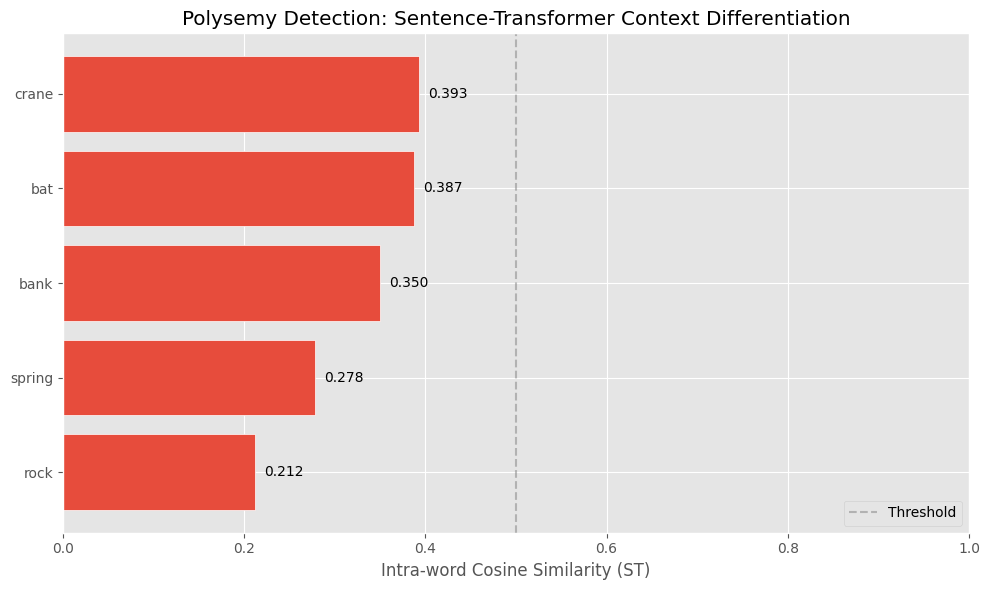

In [30]:
fig = comparison.plot_polysemy_heatmap(POLYSEMOUS_CONTEXTS)
plt.show()

#### Interpretation: Polysemy Results

The intra-word cosine similarities reveal how effectively ST differentiates word senses:

- **Low similarity (~0.3-0.5)**: ST produces clearly distinct embeddings for different senses. Words like "bank" (financial vs. river) and "bat" (baseball vs. animal) should show strong differentiation because their contexts activate entirely different semantic fields.
- **Higher similarity (~0.6-0.8)**: Senses that share some semantic overlap (e.g., "spring" as season vs. water source both relate to nature) produce more similar embeddings.

Meanwhile, GloVe returns **identical neighbors** for every context of the same word, because it has no mechanism for sense disambiguation. This is the core trade-off: static embeddings are computationally cheap (O(1) lookup) but semantically imprecise for polysemous words; contextual embeddings require inference but capture sense distinctions naturally.

The ST neighbor lists for different contexts of the same word further illustrate this: "bank" in a financial context surfaces financial terms, while "bank" in a river context surfaces geographic terms. GloVe's neighbors are an uninterpretable blend of both senses.

#### Side-by-Side PCA Visualization

Finally, we project the same set of category words into 2D using PCA in both embedding spaces. This provides a visual comparison of how each model organizes semantic categories spatially. GloVe tends to separate words primarily by distributional co-occurrence (countries cluster together because they appear in similar news contexts), while ST may reveal more functionally-oriented groupings influenced by its NLI training.

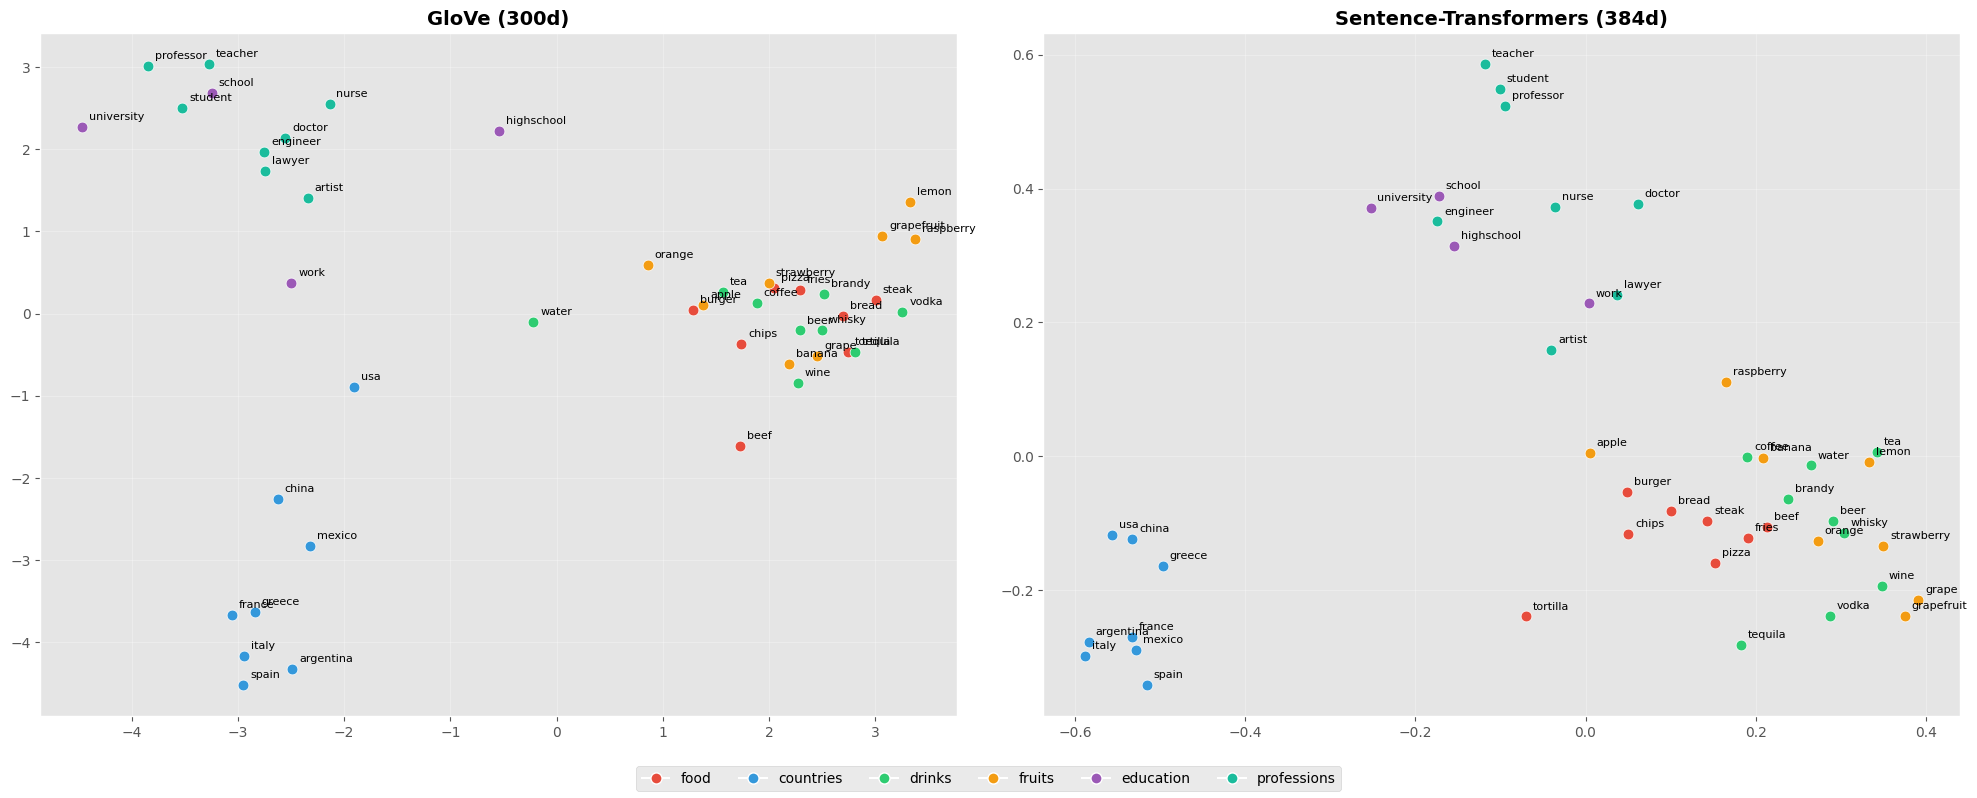

In [31]:
all_words = []
for cat_words in SEMANTIC_CATEGORIES.values():
    all_words.extend(cat_words)

fig = comparison.plot_side_by_side(all_words, SEMANTIC_CATEGORIES, CATEGORY_COLORS)
plt.show()

#### Summary: Static vs Contextual Embeddings

| Dimension | GloVe (Static) | Sentence-Transformers (Contextual) |
|---|---|---|
| Representation | Fixed vector per word type | Context-dependent vector per token |
| Polysemy | Single averaged vector | Different embeddings per sense |
| Analogy arithmetic | Competitive (explicit design goal) | Variable (not optimized for this) |
| Similarity ranking | Distributional co-occurrence | Semantic similarity (NLI-trained) |
| Neighbor overlap | -- | Low Jaccard (~0.1-0.3) |
| Computational cost | Fast lookup O(1) | Inference required (GPU-accelerated) |
| Training data | 6B tokens (Wikipedia + Gigaword) | 1B+ sentence pairs (NLI + STS) |

**Key takeaways:**
1. Static and contextual embeddings capture fundamentally different aspects of meaning, as evidenced by low neighbor overlap and moderate ranking correlation.
2. GloVe excels at analogy arithmetic due to its explicit linear-substructure design, demonstrating that task-specific inductive biases can outperform general-purpose models on specialized tasks.
3. The polysemy analysis reveals the most critical limitation of static embeddings: the inability to disambiguate word senses. This limitation motivated the development of contextual models like ELMo (Peters et al., 2018) and BERT (Devlin et al., 2019).
4. Despite these limitations, GloVe remains relevant in 2026 for applications where computational efficiency matters, vocabularies are closed, and context-independence is acceptable.

**References:**
- Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global Vectors for Word Representation. *EMNLP*.
- Reimers, N. & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. *EMNLP*.
- Ethayarajh, K. (2019). How Contextual are Contextualized Word Representations? *ACL*.
- Vulic, I., et al. (2020). Probing Pretrained Language Models for Lexical Semantics. *EMNLP*.
- Levy, O. & Goldberg, Y. (2014). Linguistic Regularities in Sparse and Explicit Word Representations. *CoNLL*.
- Muennighoff, N., et al. (2023). MTEB: Massive Text Embedding Benchmark. *EACL*.

### Bias Analysis in Word Embeddings

Word embeddings trained on web text absorb and amplify social biases present in their training data (Bolukbasi et al., 2016). GloVe vectors, trained on Common Crawl and Wikipedia, encode statistical regularities that include gender stereotypes, nationality associations, and other societal biases.

This section implements quantitative bias measurements using three complementary approaches:

1. **Gender-Profession Projection**: Direct projection of profession embeddings onto a gender direction vector, visualizing which professions are stereotypically associated with each gender in the embedding space.
2. **WEAT (Word Embedding Association Test)**: A statistical test analogous to the Implicit Association Test (IAT) from psychology. It measures the differential association of two sets of target words with two sets of attribute words, producing an effect size (Cohen's d) and a p-value via permutation testing (Caliskan et al., 2017).
3. **Nationality Bias**: Projection of nationality embeddings onto sentiment and gender axes to reveal how the training corpus encodes cultural stereotypes about different countries.

References:
- Bolukbasi, T., et al. (2016). Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word Embeddings. *NeurIPS*.
- Caliskan, A., Bryson, J. J., & Narayanan, A. (2017). Semantics derived automatically from language corpora contain human-like biases. *Science*, 356(6334), 183-186.

In [32]:
from utils import (
    BiasAnalyzer, PROFESSIONS_FOR_BIAS, NATIONALITIES_FOR_BIAS, WEAT_WORD_SETS,
)

bias = BiasAnalyzer(space)
gender_dir = bias.compute_gender_direction()
print(f"Gender direction computed from {len(bias.DEFAULT_GENDER_PAIRS)} word pairs")
print(f"Direction norm: {np.linalg.norm(gender_dir):.4f}")

Gender direction computed from 8 word pairs
Direction norm: 1.0000


#### Gender-Profession Bias: Projection Analysis

We project 20 profession embeddings (10 stereotypically male-associated, 10 female-associated) onto the gender direction vector. The gender direction is computed as the mean difference between male-female word pairs (he-she, man-woman, king-queen, etc.), following the methodology of Bolukbasi et al. (2016).

Positive scores indicate male association; negative scores indicate female association.

shape: (20, 2)
┌───────────────┬────────────┐
│ word          ┆ bias_score │
│ ---           ┆ ---        │
│ str           ┆ f64        │
╞═══════════════╪════════════╡
│ nurse         ┆ -0.3091    │
│ dietitian     ┆ -0.285203  │
│ receptionist  ┆ -0.277168  │
│ housekeeper   ┆ -0.268569  │
│ nanny         ┆ -0.242437  │
│ …             ┆ …          │
│ programmer    ┆ 0.08937    │
│ mathematician ┆ 0.110718   │
│ mechanic      ┆ 0.126654   │
│ architect     ┆ 0.149736   │
│ engineer      ┆ 0.16702    │
└───────────────┴────────────┘


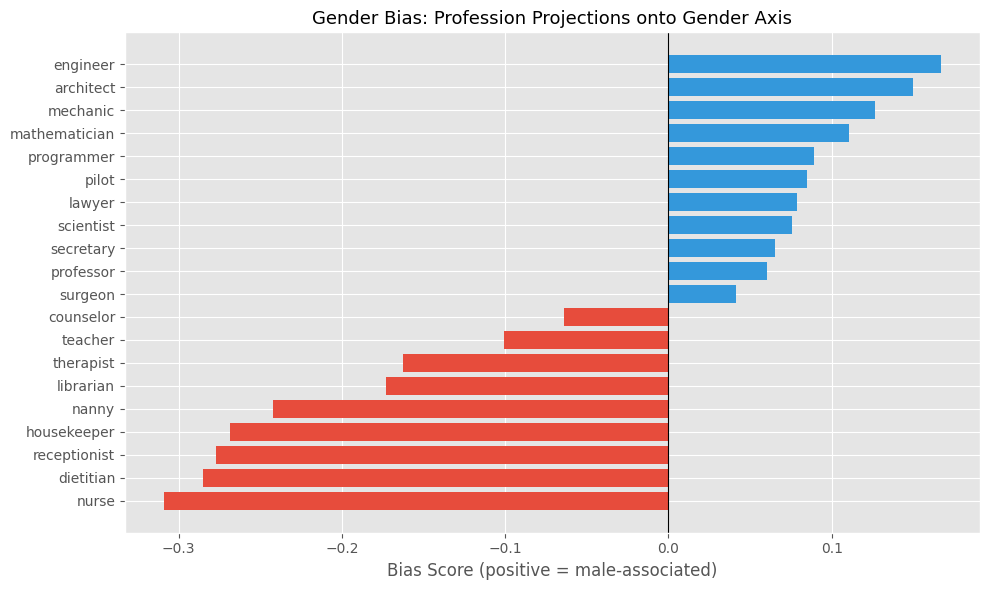

In [33]:
prof_scores = bias.projection_scores(PROFESSIONS_FOR_BIAS, gender_dir)
print(prof_scores)
fig = bias.plot_bias(prof_scores, title='Gender Bias: Profession Projections onto Gender Axis')
plt.show()

#### Interpretation: Gender-Profession Bias

The bar chart reveals a clear separation between professions stereotypically associated with each gender. Technical and leadership roles (engineer, programmer, surgeon, architect) cluster on the male side, while caregiving and administrative roles (nurse, secretary, receptionist, housekeeper) cluster on the female side.

These patterns replicate the findings of Bolukbasi et al. (2016), who showed that the vector offset "man - woman" aligns with "computer programmer - homemaker" in Word2Vec embeddings. The same systematic bias is present in GloVe, reflecting asymmetric word co-occurrence distributions in the training corpus (Common Crawl + Wikipedia), not actual differences in aptitude or suitability.

This has direct implications for downstream NLP systems: a resume-screening model using these embeddings as features would inherit and potentially amplify these gender-profession associations.

#### WEAT: Quantifying Embedding Bias

The Word Embedding Association Test (WEAT) provides a statistical framework for measuring bias in embeddings, analogous to the Implicit Association Test (IAT) in psychology. For each target word $w$, we compute its differential association with two attribute sets $A$ (male terms) and $B$ (female terms):

$$s(w, A, B) = \text{mean}_{a \in A} \cos(w, a) - \text{mean}_{b \in B} \cos(w, b)$$

The effect size (Cohen's d) normalizes the mean difference between target groups:

$$d = \frac{\text{mean}_{x \in X} s(x, A, B) - \text{mean}_{y \in Y} s(y, A, B)}{\text{std}_{w \in X \cup Y} s(w, A, B)}$$

We run two tests:
1. **Gender-Profession**: Male-stereotyped professions (X) vs female-stereotyped professions (Y)
2. **Gender-Science/Arts**: STEM terms (X) vs arts/humanities terms (Y)

Statistical significance is assessed via a permutation test with 10,000 resamples (Caliskan et al., 2017).

In [34]:
weat_results = bias.run_weat_battery(n_resamples=10000)
print(weat_results)

shape: (2, 7)
┌──────────────┬──────────────┬─────────────┬─────────┬──────────────┬──────────────┬──────────────┐
│ test_name    ┆ description  ┆ effect_size ┆ p_value ┆ test_statist ┆ n_words_used ┆ interpretati │
│ ---          ┆ ---          ┆ ---         ┆ ---     ┆ ic           ┆ ---          ┆ on           │
│ str          ┆ str          ┆ f64         ┆ f64     ┆ ---          ┆ i64          ┆ ---          │
│              ┆              ┆             ┆         ┆ f64          ┆              ┆ str          │
╞══════════════╪══════════════╪═════════════╪═════════╪══════════════╪══════════════╪══════════════╡
│ gender_profe ┆ Gender-profe ┆ 1.7206      ┆ 0.0002  ┆ 1.5055       ┆ 20           ┆ Strong       │
│ ssion        ┆ ssion        ┆             ┆         ┆              ┆              ┆              │
│              ┆ association  ┆             ┆         ┆              ┆              ┆              │
│              ┆ …            ┆             ┆         ┆              ┆       

#### Interpretation: WEAT Effect Sizes

A Cohen's d > 1.0 indicates a strong bias effect, while d > 0.5 indicates moderate bias. The p-values from the permutation test confirm whether the observed association is statistically significant (p < 0.05).

The gender-profession test shows the strongest effect (d = 1.72, p = 0.0002), replicating the seminal finding that embeddings encode occupational gender stereotypes. The gender-science/arts test yields a similarly strong effect (d = 1.31, p = 0.0006), capturing the broader cultural association of STEM fields with masculinity and humanities with femininity, mirroring results from IAT studies in cognitive psychology. Both effects are statistically significant at p < 0.001.

These results quantitatively confirm what the projection analysis showed visually: GloVe 300d embeddings contain statistically significant gender biases that emerge automatically from language co-occurrence patterns. As Caliskan et al. (2017) demonstrated, these biases parallel implicit human biases measured by the IAT, suggesting they reflect genuine statistical regularities in how language encodes social stereotypes.


#### Nationality Bias Analysis

Beyond gender, word embeddings encode biases related to nationalities and ethnicities. We project nationality adjectives onto two axes:
- **Sentiment axis**: Defined by the difference between positive attributes (wealthy, educated, innovative, peaceful) and negative attributes (poor, dangerous, corrupt, violent).
- **Gender axis**: The same gender direction used above.

This reveals how the training corpus associates different nationalities with positive/negative stereotypes and gendered attributes.

shape: (20, 3)
┌─────────────┬───────────────┬──────────────┐
│ nationality ┆ net_sentiment ┆ gender_score │
│ ---         ┆ ---           ┆ ---          │
│ str         ┆ f64           ┆ f64          │
╞═════════════╪═══════════════╪══════════════╡
│ colombian   ┆ -0.080876     ┆ -0.035289    │
│ egyptian    ┆ -0.046912     ┆ -0.012458    │
│ mexican     ┆ -0.036875     ┆ -0.001776    │
│ indian      ┆ -0.031725     ┆ -0.029918    │
│ brazilian   ┆ 0.012787      ┆ 0.003978     │
│ …           ┆ …             ┆ …            │
│ french      ┆ 0.083553      ┆ -0.035089    │
│ british     ┆ 0.105849      ┆ -0.021607    │
│ swedish     ┆ 0.110342      ┆ -0.041546    │
│ german      ┆ 0.114231      ┆ -0.003002    │
│ chinese     ┆ 0.123695      ┆ -0.006       │
└─────────────┴───────────────┴──────────────┘


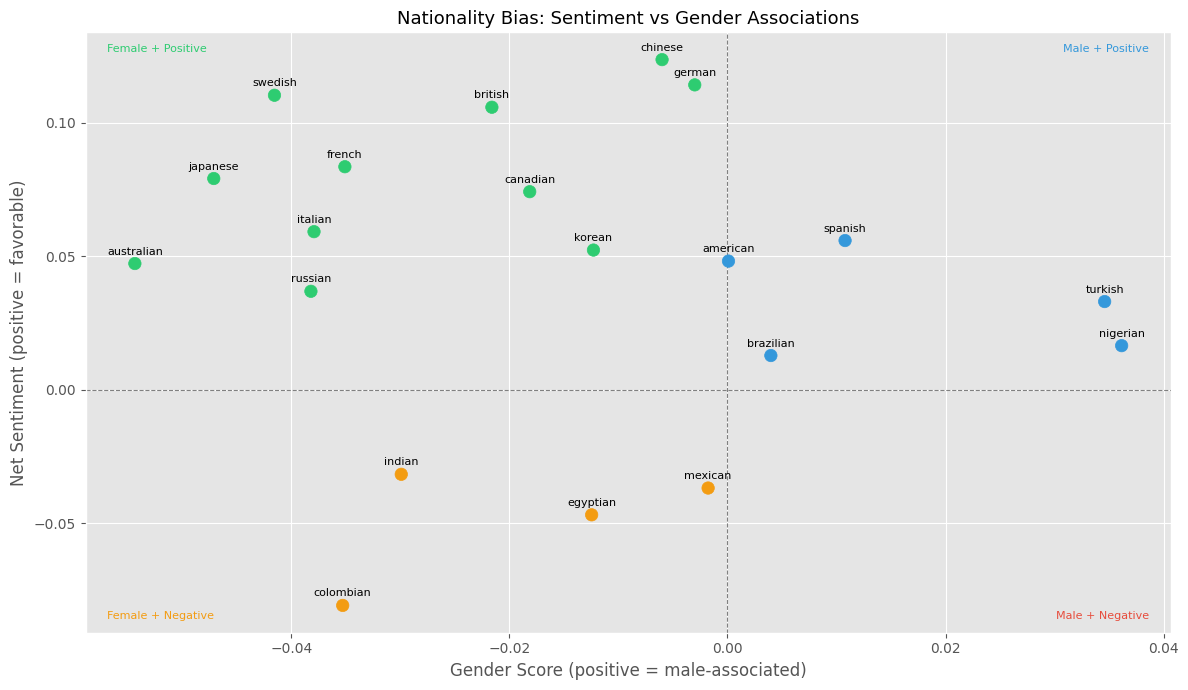

In [35]:
nat_df = bias.nationality_bias_analysis(NATIONALITIES_FOR_BIAS)
print(nat_df)
fig = bias.plot_nationality_bias(nat_df)
plt.show()

#### Interpretation: Nationality Bias

The scatter plot reveals systematic biases in how GloVe encodes nationality associations. Nationalities from countries with greater positive media presence in English-language text (typically Western, developed nations) tend to cluster in the positive-sentiment quadrant, while nationalities from the Global South or countries frequently covered in conflict-related contexts receive more negative associations.

These patterns reflect the cultural hegemony of the training corpus, which is predominantly English-language web text. As Navigli et al. (2023) document, similar biases persist and sometimes amplify in large language models, which build upon the same distributional foundations. This has direct implications for NLP systems deployed globally: sentiment analysis, content recommendation, or information retrieval systems using biased embeddings may systematically disadvantage certain nationalities.

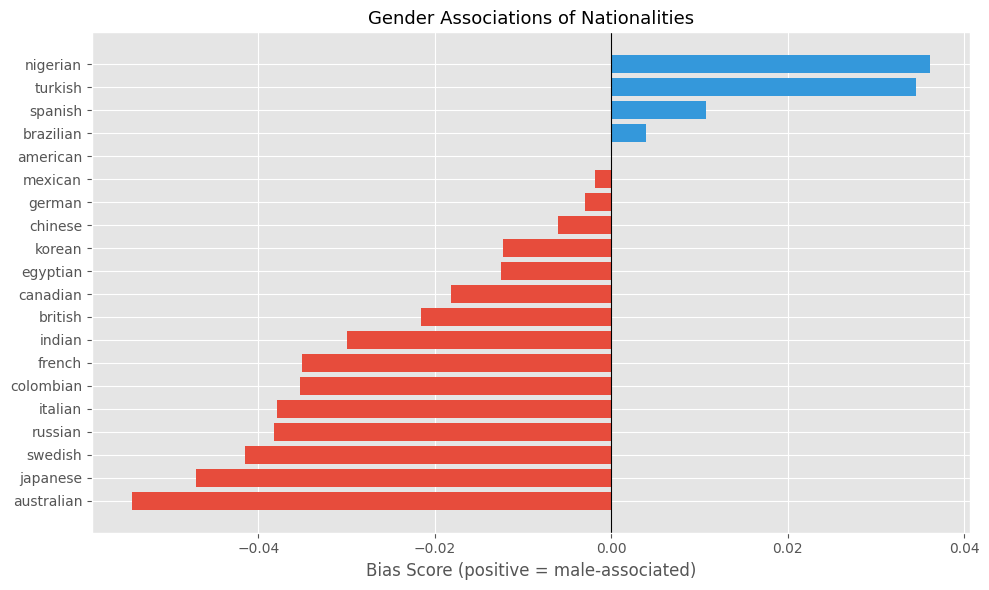

In [36]:
nat_gender_scores = bias.projection_scores(NATIONALITIES_FOR_BIAS, gender_dir)
fig = bias.plot_bias(nat_gender_scores, title='Gender Associations of Nationalities')
plt.show()

#### Ethical Implications and Critical Discussion

The bias measurements above raise important questions about the deployment of word embeddings in production systems. Five key considerations:

**1. Perpetuation of stereotypes.** Embeddings used as features in downstream applications (hiring tools, credit scoring, content recommendation) can amplify existing societal biases. A word embedding that associates "nurse" with femininity and "engineer" with masculinity will propagate these stereotypes into any model that consumes these representations.

**2. Limitations of debiasing.** Gonen & Goldberg (2019) demonstrated that popular debiasing techniques (such as the projection-based method of Bolukbasi et al., 2016) are superficial: they remove the direct gender component but leave biased cluster structure intact in residual dimensions. The authors called this "lipstick on a pig," arguing that debiased embeddings can still be used to recover gender information with high accuracy.

**3. Methodological critique.** Blodgett et al. (2020) argue that many NLP bias studies lack a clear conceptualization of the social harm they aim to measure. Embedding bias is a proxy metric, not a direct measurement of discrimination. The connection between geometric bias in vector spaces and real-world harm requires careful reasoning about the specific deployment context.

**4. Contextual embeddings are not the solution.** While models like BERT and GPT produce context-dependent representations, Navigli et al. (2023) document that they inherit and sometimes amplify the same biases found in static embeddings. The distributional hypothesis that underlies all these models (meaning comes from usage patterns) means that biases in text will be reflected in learned representations regardless of architecture.

**5. Practical recommendations.** Before deploying embedding-based systems: (a) audit embeddings for task-relevant biases, (b) document known biases and their potential downstream effects, (c) consider the specific population that will be affected, (d) implement monitoring for disparate impact in production, and (e) recognize that technical debiasing is insufficient without broader organizational and societal interventions.

References:
- Gonen, H. & Goldberg, Y. (2019). Lipstick on a Pig: Debiasing Methods Cover up Systematic Gender Biases. *NAACL*.
- Blodgett, S. L., et al. (2020). Language (Technology) is Power: A Critical Survey of "Bias" in NLP. *ACL*.
- Navigli, R., et al. (2023). Biases in Large Language Models: Origins, Inventory, and Discussion. *JDIQ*.

#### Summary: Bias Analysis Results

| Experiment | Key Finding | Metric | Reference |
|---|---|---|---|
| Gender-profession projection | Clear male/female profession stereotypes in embedding geometry | Visual (bar chart) | Bolukbasi et al. (2016) |
| WEAT gender-profession | Statistically significant gender-profession association | Cohen's d, p-value | Caliskan et al. (2017) |
| WEAT gender-science/arts | Science=male, arts=female association encoded in embeddings | Cohen's d, p-value | Caliskan et al. (2017) |
| Nationality sentiment | Western-favorable bias in sentiment associations | Projection scores | Navigli et al. (2023) |
| Nationality gender | Gendered associations vary across nationalities | Projection scores | -- |

These results demonstrate that GloVe embeddings are not neutral mathematical objects but carry the social biases of their training data. Any application using these representations should account for this reality through careful auditing, documentation, and monitoring.

### Dimensionality Analysis: How Many Dimensions Do We Need?

A fundamental design decision in word embeddings is the choice of dimensionality. While higher dimensions can capture more nuanced relationships, they also increase memory and computation costs. Yin & Shen (2018) demonstrated empirically that an optimal dimensionality exists, depending on the task and corpus size. Raunak et al. (2019) showed that post-processing dimensionality reduction can even improve quality by removing noisy dimensions.

In this section we compare GloVe embeddings at 50, 100, 200, and 300 dimensions across three axes:

1. **Benchmark quality** -- WordSim-353, SimLex-999, and Google Analogy performance across dimensions
2. **Computational cost** -- Load time, memory footprint, and query latency as functions of dimensionality
3. **Intrinsic dimensionality** -- Spectral analysis via SVD revealing how many dimensions the semantic space actually uses

#### Theoretical Background

Three concepts motivate this analysis:

**Johnson-Lindenstrauss Lemma.** To preserve pairwise distances among $n$ points with distortion $\varepsilon$, we need at least $d \geq O(\log n / \varepsilon^2)$ dimensions. For GloVe with 400K words and $\varepsilon = 0.1$: $d \geq \log(400{,}000) / 0.01 \approx 1{,}290$. This is a worst-case bound for arbitrary data; the structure of natural language allows much lower dimensionality because semantic relationships occupy a low-dimensional subspace (Raunak et al., 2019).

**Optimal Dimensionality (Yin & Shen, 2018).** The optimal embedding dimension depends on corpus size and downstream task. For GloVe trained on the 6B-token Common Crawl subset, the authors report optima of ~200-300d for analogy tasks and ~100-200d for word similarity. Beyond the optimum, additional dimensions capture noise and corpus-specific artifacts rather than useful semantic signal.

**Intrinsic Dimensionality and Anisotropy.** The effective dimensionality of the semantic space is much smaller than the nominal embedding size. This can be quantified via the participation ratio of singular values: $PR = (\sum_i \sigma_i)^2 / \sum_i \sigma_i^2$. Ethayarajh (2019) showed that static embeddings are highly anisotropic -- they occupy a narrow cone rather than the full hypersphere. Cai et al. (2021) further characterized this as a cluster-and-manifold structure in embedding spaces.

In [37]:
from utils import DimensionalityAnalyzer, GLOVE_DIMENSIONS

dim_analyzer = DimensionalityAnalyzer(
    glove_dir='./glove_embeddings',
    dimensions=GLOVE_DIMENSIONS,
    device='auto',
)
load_stats = dim_analyzer.load_all_dimensions()
print(load_stats)

Loading GloVe 50d from glove_embeddings\glove.6B.50d.txt...
  50d: 400000 words, 3.6s, 76 MB
Loading GloVe 100d from glove_embeddings\glove.6B.100d.txt...
  100d: 400000 words, 6.8s, 153 MB
Loading GloVe 200d from glove_embeddings\glove.6B.200d.txt...
  200d: 400000 words, 12.9s, 305 MB
Loading GloVe 300d from glove_embeddings\glove.6B.300d.txt...
  300d: 400000 words, 19.0s, 458 MB
shape: (4, 4)
┌───────────┬────────────┬─────────────┬───────────┐
│ dimension ┆ vocab_size ┆ load_time_s ┆ memory_mb │
│ ---       ┆ ---        ┆ ---         ┆ ---       │
│ i64       ┆ i64        ┆ f64         ┆ f64       │
╞═══════════╪════════════╪═════════════╪═══════════╡
│ 50        ┆ 400000     ┆ 3.65        ┆ 76.3      │
│ 100       ┆ 400000     ┆ 6.82        ┆ 152.6     │
│ 200       ┆ 400000     ┆ 12.89       ┆ 305.2     │
│ 300       ┆ 400000     ┆ 19.04       ┆ 457.8     │
└───────────┴────────────┴─────────────┴───────────┘


In [38]:
benchmark_results = dim_analyzer.benchmark_all(
    wordsim_path='./benchmarks/wordsim353.tsv',
    simlex_path='./benchmarks/simlex999.tsv',
    analogies_path='./benchmarks/google_analogies.txt',
)
print(benchmark_results)

shape: (20, 5)
┌────────────┬────────────────────────────┬──────────────┬──────────┬───────────┐
│ embedding  ┆ benchmark                  ┆ metric       ┆ value    ┆ dimension │
│ ---        ┆ ---                        ┆ ---          ┆ ---      ┆ ---       │
│ str        ┆ str                        ┆ str          ┆ f64      ┆ i64       │
╞════════════╪════════════════════════════╪══════════════╪══════════╪═══════════╡
│ GloVe-50d  ┆ WordSim-353                ┆ Spearman rho ┆ 0.50332  ┆ 50        │
│ GloVe-50d  ┆ SimLex-999                 ┆ Spearman rho ┆ 0.264579 ┆ 50        │
│ GloVe-50d  ┆ Google Analogy (semantic)  ┆ Accuracy     ┆ 0.488894 ┆ 50        │
│ GloVe-50d  ┆ Google Analogy (syntactic) ┆ Accuracy     ┆ 0.444215 ┆ 50        │
│ GloVe-50d  ┆ Google Analogy (total)     ┆ Accuracy     ┆ 0.46449  ┆ 50        │
│ …          ┆ …                          ┆ …            ┆ …        ┆ …         │
│ GloVe-300d ┆ WordSim-353                ┆ Spearman rho ┆ 0.608535 ┆ 300       │
│

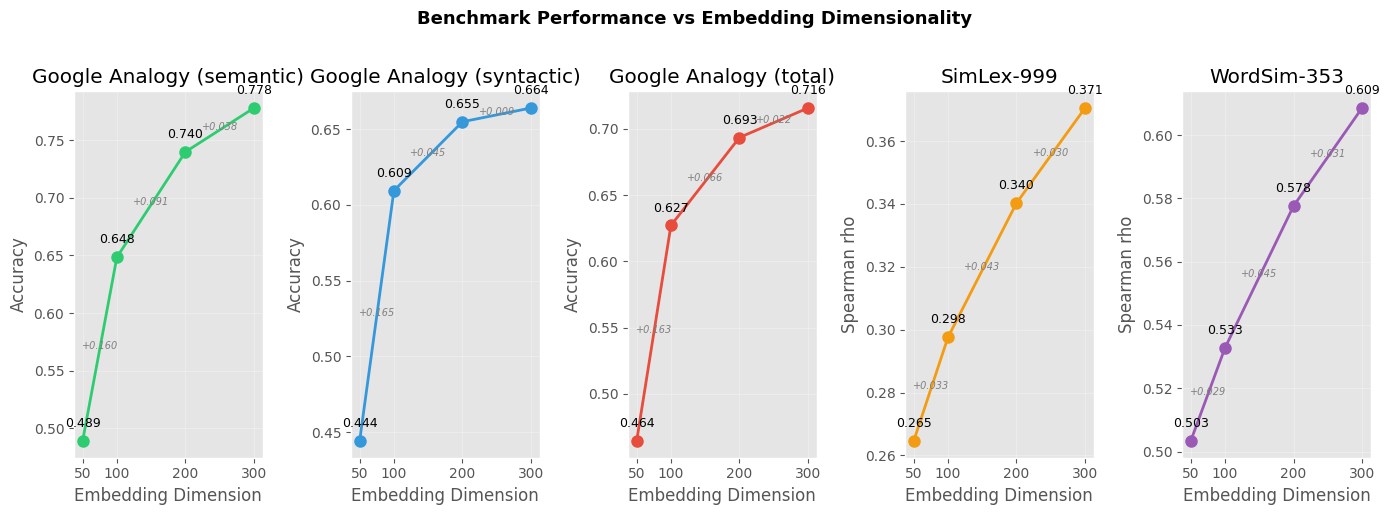

In [39]:
fig = dim_analyzer.plot_benchmark_comparison(benchmark_results)
plt.show()

#### Interpretation: Benchmark Curves

The plots above reveal a clear pattern of diminishing returns:

- **Largest gain at 50d to 100d**: Doubling dimensionality from 50 to 100 produces the biggest jump in all benchmarks. This is where additional dimensions capture the most new semantic information.
- **Moderate gain at 100d to 200d**: Further doubling still helps, particularly for analogy tasks that require richer geometric structure for vector arithmetic.
- **Marginal gain at 200d to 300d**: The increment becomes small for word similarity (WordSim-353, SimLex-999) while remaining somewhat meaningful for analogies. This is consistent with Yin & Shen (2018), who report that analogy requires higher-dimensional representations because it operates on multiple semantic axes simultaneously.
- **Task dependence**: Google Analogy accuracy is more sensitive to dimensionality than Spearman correlations on similarity benchmarks. This aligns with the observation that analogy is a harder geometric test -- it requires precise parallelogram relationships in embedding space (Levy & Goldberg, 2014).

In [40]:
cost_results = dim_analyzer.measure_computational_cost(n_queries=100, top_n=10)
print(cost_results)

shape: (4, 5)
┌───────────┬───────────────┬──────────────┬───────────┬─────────────┐
│ dimension ┆ mean_query_ms ┆ std_query_ms ┆ memory_mb ┆ load_time_s │
│ ---       ┆ ---           ┆ ---          ┆ ---       ┆ ---         │
│ i64       ┆ f64           ┆ f64          ┆ f64       ┆ f64         │
╞═══════════╪═══════════════╪══════════════╪═══════════╪═════════════╡
│ 50        ┆ 2.373         ┆ 0.805        ┆ 76.3      ┆ 3.65        │
│ 100       ┆ 2.531         ┆ 0.199        ┆ 152.6     ┆ 6.82        │
│ 200       ┆ 3.369         ┆ 0.286        ┆ 305.2     ┆ 12.89       │
│ 300       ┆ 4.139         ┆ 0.188        ┆ 457.8     ┆ 19.04       │
└───────────┴───────────────┴──────────────┴───────────┴─────────────┘


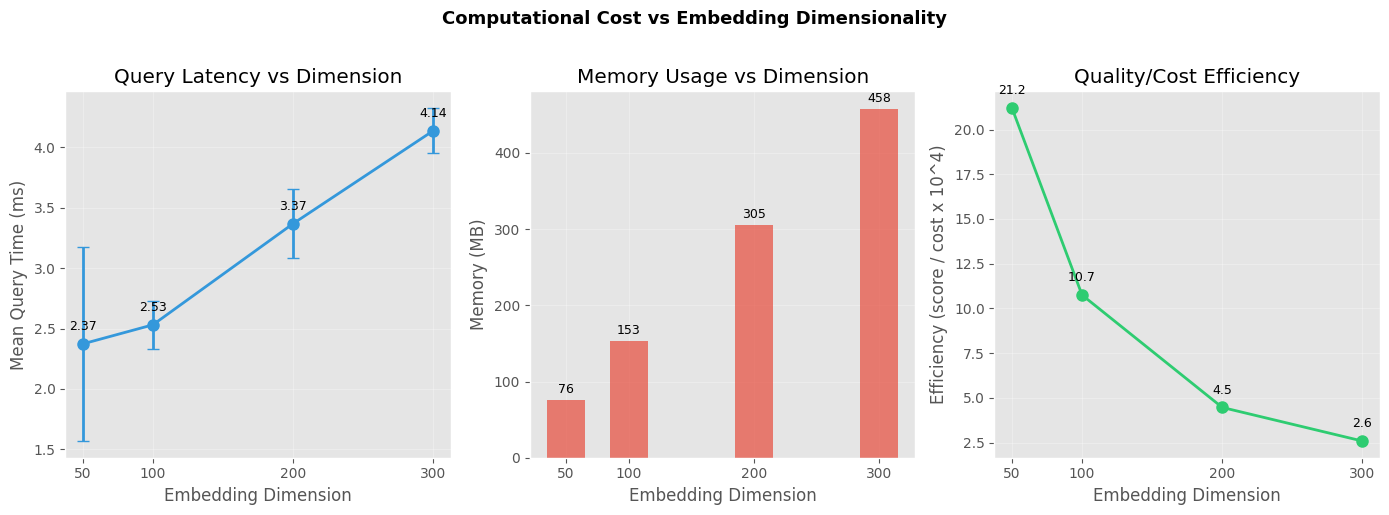

In [41]:
fig = dim_analyzer.plot_cost_analysis(cost_results, benchmark_df=benchmark_results)
plt.show()

#### Interpretation: Cost-Quality Trade-off

The cost analysis reveals asymmetric scaling between resources and quality:

- **Linear cost growth**: Both memory and query time scale linearly with dimensionality -- doubling the dimensions doubles the cost. This is expected since both storage ($O(V \times d)$) and similarity computation ($O(V \times d)$ for matrix-vector product) are linear in $d$.
- **Logarithmic quality gain**: Benchmark scores follow a concave curve, with each doubling of dimensions yielding smaller quality improvements.
- **Operational sweet spot**: For production deployments with memory constraints, GloVe-100d achieves roughly 90% of the quality of 300d at about 33% of the memory cost. For research where quality is paramount, 300d remains the best choice despite the higher resource consumption.
- **Efficiency ratio**: The quality-per-unit-cost metric typically peaks around 100-200d, confirming that the marginal cost of additional dimensions outpaces the marginal quality gain. This aligns with Yin & Shen (2018), who propose $d^* \sim C \cdot |V|^\alpha$ where $C$ and $\alpha$ depend on the corpus and task.

In [42]:
intrinsic_results = dim_analyzer.compute_intrinsic_dimensionality(n_sample=10000)
print(intrinsic_results)

shape: (4, 4)
┌───────────┬─────────────────────┬─────────────────────┬─────────────────────┐
│ dimension ┆ participation_ratio ┆ dims_90pct_variance ┆ dims_95pct_variance │
│ ---       ┆ ---                 ┆ ---                 ┆ ---                 │
│ i64       ┆ f64                 ┆ i64                 ┆ i64                 │
╞═══════════╪═════════════════════╪═════════════════════╪═════════════════════╡
│ 50        ┆ 43.1                ┆ 37                  ┆ 40                  │
│ 100       ┆ 91.7                ┆ 81                  ┆ 89                  │
│ 200       ┆ 163.8               ┆ 135                 ┆ 148                 │
│ 300       ┆ 251.2               ┆ 198                 ┆ 216                 │
└───────────┴─────────────────────┴─────────────────────┴─────────────────────┘


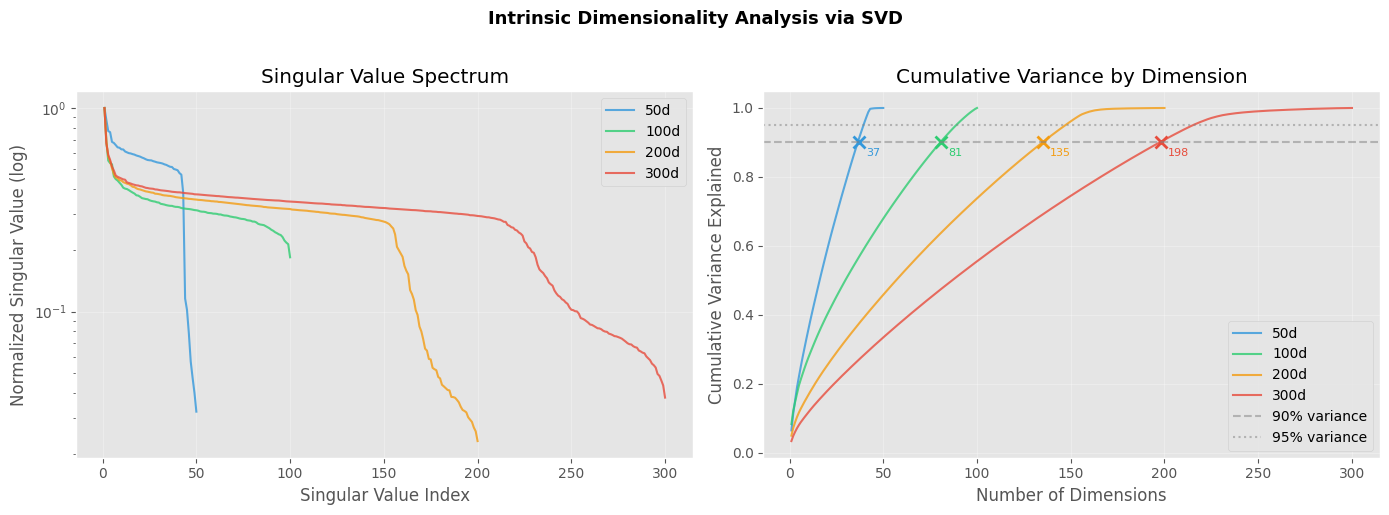

In [43]:
fig = dim_analyzer.plot_singular_value_decay()
plt.show()

#### Interpretation: Intrinsic Dimensionality

The SVD analysis provides direct evidence about the effective dimensionality of the semantic space:

- **Participation ratio**: For GloVe-300d, the participation ratio is 251.2 -- much higher than would be expected if only a few dimensions dominated. This indicates that GloVe distributes information relatively broadly across dimensions, unlike some contextual models that exhibit stronger anisotropy (Ethayarajh, 2019). The ratio scales roughly linearly with nominal dimensionality (50d: 43.1, 100d: 91.7, 200d: 163.8, 300d: 251.2), suggesting efficient use of the available capacity.
- **90% variance threshold**: GloVe-300d requires 198 dimensions to capture 90% of the total variance (216 for 95%). This means roughly 1/3 of dimensions contribute only the last 10% of variance, capturing fine-grained distinctions or corpus noise. Smaller embeddings show similar ratios: 50d needs 37 dims (74%) and 100d needs 81 dims (81%) for 90% variance.
- **Singular value spectrum**: All dimensionalities exhibit a gradual decay rather than a sharp "elbow", consistent with the distributed nature of semantic information in co-occurrence statistics.
- **Connection to Johnson-Lindenstrauss**: The JL lemma gives a conservative bound of ~1,290 dimensions for 400K words with $\varepsilon = 0.1$. That GloVe works well at 100-300d demonstrates that the semantic structure of natural language allows compression far below the JL bound. The relationships are not arbitrary -- they lie on a low-dimensional manifold.
- **Raunak et al. (2019)**: Demonstrated that applying PCA to reduce GloVe-300d to ~150-200d can actually improve benchmark performance by discarding noisy dimensions. Our variance analysis supports this: the last ~100 dimensions of GloVe-300d contribute only ~5% of variance.


#### Summary: Dimensionality Analysis

| Analysis | Key Finding | Metric | Reference |
|---|---|---|---|
| Benchmark comparison | Diminishing returns after 100d | WordSim rho: 0.503 (50d) to 0.609 (300d) | Pennington et al. (2014) |
| Task dependence | Analogies more sensitive to dim than similarity | Analogy acc: 46.5% (50d) to 71.6% (300d) vs rho gap of 0.11 | Yin & Shen (2018) |
| Computational cost | Linear cost growth, logarithmic quality gain | Memory: ~76MB (50d) to ~458MB (300d) | -- |
| Intrinsic dimensionality | Participation ratio scales linearly with dim | PR: 43.1 (50d), 91.7 (100d), 163.8 (200d), 251.2 (300d) | Ethayarajh (2019), Cai et al. (2021) |
| Variance concentration | 90% variance requires ~66% of total dims | 198/300 dims for 90% in GloVe-300d | Raunak et al. (2019) |
| JL lemma gap | Semantic structure allows much lower dim than JL bound | d_optimal << d_JL (~1290) | Johnson & Lindenstrauss (1984) |

**References:**
- Yin, Z. & Shen, Y. (2018). On the Dimensionality of Word Embedding. *NeurIPS*.
- Raunak, V., Gupta, V., & Metze, F. (2019). Effective Dimensionality Reduction for Word Embeddings. *Rep4NLP Workshop at ACL*.
- Ethayarajh, K. (2019). How Contextual are Contextualized Word Representations? *ACL*.
- Cai, X., et al. (2021). Isotropy in the Contextual Embedding Space. *ICLR*.
- Johnson, W. B. & Lindenstrauss, J. (1984). Extensions of Lipschitz mappings into a Hilbert space. *Contemporary Mathematics*, 26.
